In [3]:
import pytexlib as ptl
import vedo
vedo.settings.default_backend="vtk"
import numpy as np
import os

## Read Textile from XML


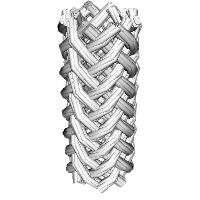

In [4]:
xml_file_uir=os.path.join(os.curdir,"sample_files","tubu.txm")
textile = ptl.from_xml(xml_file_uir)
textile.as_vedo_assembly()

## Coloring


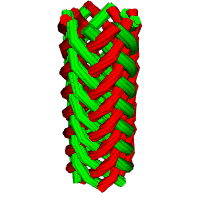

In [5]:
textile.colormap_yarn_groups()
textile.as_vedo_assembly()


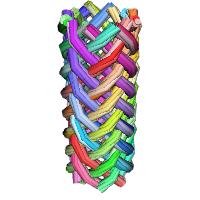

In [6]:
textile.colormap_yarns()
textile.as_vedo_assembly()


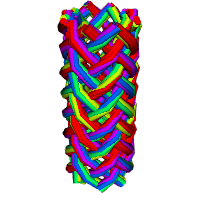

In [7]:
textile.colormap_fibers()
textile.as_vedo_assembly()

## Modify Resolution

### Resample by Count

In [8]:
textile = ptl.from_xml('tubu.txm')

vplt=vedo.Plotter(N=2)
a=textile[0][0][0].make_resolution_assembly()    
vplt.at(0).add(a.add_scalarbar(),vedo.Text2D("Before Resampling"))

for yg_idx, yarn_group in enumerate(textile.yarn_groups):
    for ya_idx, yarn in enumerate(yarn_group.yarns):        
        for f_idx, fiber in enumerate(yarn.fibers):
            fiber.resample_polyline_by_count(40)
            
a=textile[0][0][0].make_resolution_assembly()            
vplt.at(1).add(a.add_scalarbar(),vedo.Text2D("After Resampling"))
vplt.show().interactive().close()


FileNotFoundError: [Errno 2] No such file or directory: 'tubu.txm'

## Resample by distance

In [ ]:
textile = ptl.from_xml('tubu.txm')

vplt=vedo.Plotter(N=2)
a=textile[0][0][0].make_resolution_assembly()    
vplt.at(0).add(a.add_scalarbar(),vedo.Text2D("Before Resampling"))

for yg_idx, yarn_group in enumerate(textile.yarn_groups):
    for ya_idx, yarn in enumerate(yarn_group.yarns):        
        for f_idx, fiber in enumerate(yarn.fibers):
            fiber.resample_polyline_by_spacing(0.3)
            
a=textile[0][0][0].make_resolution_assembly()            
vplt.at(1).add(a.add_scalarbar(),vedo.Text2D("After Resampling"))
vplt.show().interactive().close()


# Smoothing

In [ ]:
textile = ptl.from_xml('tubu.txm')

vplt=vedo.Plotter(N=3)
# a=textile[0][0][0].make_resolution_assembly()    
a,scalarbar=textile.make_resolution_assembly()    
vplt.at(0).add(a,scalarbar,vedo.Text2D("Before Fitting B-Spline"))

for yg_idx, yarn_group in enumerate(textile.yarn_groups):
    for ya_idx, yarn in enumerate(yarn_group.yarns):        
        for f_idx, fiber in enumerate(yarn.fibers):
            fiber.fit_b_spline(order=3,smoothing=0,n_points=2000)
            
            
# a=textile[0][0][0].make_resolution_assembly()       
a,scalarbar=textile.make_resolution_assembly()         
vplt.at(1).add(a,scalarbar,vedo.Text2D("After Fitting B-Spline"))

for yg_idx, yarn_group in enumerate(textile.yarn_groups):
    for ya_idx, yarn in enumerate(yarn_group.yarns):        
        for f_idx, fiber in enumerate(yarn.fibers):
            fiber.resample_polyline_by_min_spacing(.31)
            fiber.remove_segments_by_length(min_distance=.3)
            

a,scalarbar=textile.make_resolution_assembly()         
vplt.at(2).add(a,scalarbar,vedo.Text2D("After Fitting B-Spline and Distance-Based Resampling"))

vplt.show().interactive().close()

NameError: name 'ptl' is not defined